In [5]:
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torchvision
import torchvision.utils as vutils
from torchvision import datasets, transforms
import torch
import torch.nn as nn
DEVICE = torch.device("mps")
import wandb
from sklearn.manifold import TSNE
import seaborn as sns
import torch.nn.functional as F


# Diffusion Model Process

## Setup Steps
Here's how we are going to proceed:

1. Import data similar to GAN
2. Create a UNET architecture with attention at the middle

## Training Process
For training:
- Minimize $\left| \mu_\theta(t) - \mu(t) \right|$

## Sampling Process
For sampling:
- Start at $t = T$
- Take one step forward by:
  - Making the diffusion model predict the original image $\hat{x}$
  - Then add noise in size of $t-1$ (What is exactly the noise distribution?)
- Continue taking steps forward until you hit $t = 0$

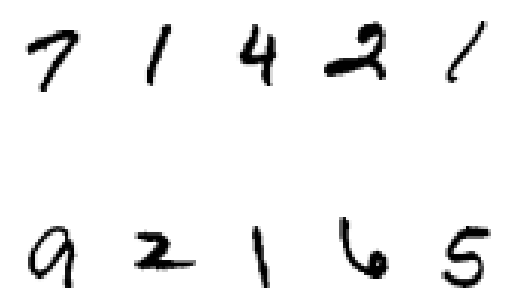

In [6]:
transform = transforms.Compose([transforms.ToTensor(),
                              transforms.Normalize((0.1307,), (0.3081,))])

trainset = datasets.MNIST('MNIST_data/', download=True, train=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)


testset = datasets.MNIST('MNIST_data/', download=True, train=False, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=1024, shuffle=True)



dataiter = iter(trainloader)
images, labels = next(dataiter)

figure = plt.figure()
num_of_images = 10
for index in range(1, num_of_images + 1):
    plt.subplot(2, 5, index)
    plt.axis('off')
    plt.imshow(images[index].numpy().squeeze(), cmap='gray_r')

In [ ]:
class U_net(nn.Module):
    def __init__(self, code_dim=64):
        super().__init__()
        # Encoder components (unchanged)
        self.code_dim = code_dim
        self.cnn_1 = nn.Conv2d(in_channels=1, out_channels=4, kernel_size=4, padding=1)
        self.max_pool_1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.cnn_2 = nn.Conv2d(in_channels=4, out_channels=16, kernel_size=4, padding=1)
        self.max_pool_2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.cnn_3 = nn.Conv2d(in_channels=16, out_channels=64, kernel_size=3, padding=1)
        self.max_pool_3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        self.linear_1 = nn.Linear(576, code_dim)
        self.non_linear = nn.LeakyReLU()
        self.tr_linear_1 = nn.Linear(code_dim, 576)
        
        # Decoder components (unchanged)
        self.conv_trans_1 = nn.ConvTranspose2d(in_channels=64, out_channels=16, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.conv_trans_2 = nn.ConvTranspose2d(in_channels=32, out_channels=4, kernel_size=4, stride=2, padding=1, output_padding=1)
        self.conv_trans_3 = nn.ConvTranspose2d(in_channels=8, out_channels=1, kernel_size=4, stride=2, padding=1, output_padding=1)
        self.cnn_up_1 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
        self.cnn_up_2 = nn.Conv2d(in_channels=8, out_channels=8, kernel_size=3, padding=1)
        self.final_conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, padding=1)
        
        # Enhanced time embedding system
        self.time_embed_base = nn.Sequential(
            nn.Linear(1, 64),
            nn.SiLU(),
            nn.Linear(64, 64)
        )
        
        # Time embedding projections for each layer
        self.time_proj_enc1 = nn.Linear(64, 4)  # For encoder layer 1
        self.time_proj_enc2 = nn.Linear(64, 16) # For encoder layer 2
        self.time_proj_enc3 = nn.Linear(64, 64) # For encoder layer 3
        self.time_proj_bottleneck = nn.Linear(64, code_dim) # For bottleneck
        self.time_proj_dec1 = nn.Linear(64, 32) # For decoder layer 1 (after skip)
        self.time_proj_dec2 = nn.Linear(64, 8)  # For decoder layer 2 (after skip)
        self.time_proj_dec3 = nn.Linear(64, 1)  # For decoder layer 3 (final)

    def forward(self, x, t=None):

        time_emb = self.time_embed_base(t.reshape(-1, 1).float())

        x1 = self.cnn_1(x)

        # Project time embedding to the right dimension and add to features
        t_emb = self.time_proj_enc1(time_emb)
        t_emb = t_emb.reshape(t_emb.shape[0], t_emb.shape[1], 1, 1)
        t_emb = t_emb.expand(-1, -1, x1.shape[2], x1.shape[3])
        x1 = x1 + t_emb
        x1 = self.non_linear(x1)
        x = self.max_pool_1(x1)
        
        x2 = self.cnn_2(x)
        
        t_emb = self.time_proj_enc2(time_emb)
        t_emb = t_emb.reshape(t_emb.shape[0], t_emb.shape[1], 1, 1)
        t_emb = t_emb.expand(-1, -1, x2.shape[2], x2.shape[3])
        
        x2 = x2 + t_emb
        x2 = self.non_linear(x2)
        x = self.max_pool_2(x2)
        
        x3 = self.cnn_3(x)
        
        t_emb = self.time_proj_enc3(time_emb)
        t_emb = t_emb.reshape(t_emb.shape[0], t_emb.shape[1], 1, 1)
        t_emb = t_emb.expand(-1, -1, x3.shape[2], x3.shape[3])

        x3 = x3 + t_emb
        x3 = self.non_linear(x3)
        x = self.max_pool_3(x3)
        
        # Bottleneck with time embedding
        x = self.flatten(x)
        x = self.linear_1(x)

        t_emb = self.time_proj_bottleneck(time_emb)
        x = x + t_emb

        z = self.non_linear(x)
        
        # Decoder path with time embedding
        x = self.tr_linear_1(z)
        x = x.view(x.shape[0], 64, 3, 3)
        x = self.conv_trans_1(x)
        
        # First skip connection with time embedding
        x = torch.cat([x, x2], dim=1)
        x = self.cnn_up_1(x)

        t_emb = self.time_proj_dec1(time_emb)
        t_emb = t_emb.reshape(t_emb.shape[0], t_emb.shape[1], 1, 1)
        t_emb = t_emb.expand(-1, -1, x.shape[2], x.shape[3])
        x = x + t_emb

        x = self.non_linear(x)
        x = self.conv_trans_2(x)
        
        # Second skip connection with time embedding
        x = torch.cat([x, x1], dim=1)
        x = self.cnn_up_2(x)
        t_emb = self.time_proj_dec2(time_emb)
        t_emb = t_emb.reshape(t_emb.shape[0], t_emb.shape[1], 1, 1)
        t_emb = t_emb.expand(-1, -1, x.shape[2], x.shape[3])
        x = x + t_emb
        x = self.non_linear(x)
        x = self.conv_trans_3(x)
        
        # Final layer with time embedding

        t_emb = self.time_proj_dec3(time_emb)
        t_emb = t_emb.reshape(t_emb.shape[0], t_emb.shape[1], 1, 1)
        t_emb = t_emb.expand(-1, -1, x.shape[2], x.shape[3])
        x = x + t_emb
            
        x = x + self.final_conv(x)
        return x